# Facial Expression Recognition - ResNet

- Train on 100% of data (no validation holdout)
-  Dropout + L2 regularization to fight overfitting


## 1. Imports

In [35]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ModelCheckpoint

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Settings

In [36]:
IMG_SIZE    = 96
CHANNELS    = 1
BATCH_SIZE  = 32
EPOCHS      = 100
NUM_CLASSES = 6

DATA_DIR    = "/kaggle/input/competitions/emotion-detection-competition/Training_data/Training_data"
TEST_DIR    = "/kaggle/input/competitions/emotion-detection-competition/test/test"
CLASS_NAMES = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise']

print("Settings ready")

Settings ready


## 3. Load ALL Training Data
> Using 100% of data no validation split.


In [37]:
def load_data(data_dir):
    images, labels = [], []
    for label_idx, class_name in enumerate(CLASS_NAMES):
        folder = os.path.join(data_dir, class_name)
        if not os.path.exists(folder):
            print(f"Folder not found: {folder}")
            continue
        files = os.listdir(folder)
        print(f"Loading {class_name}: {len(files)} images")
        for filename in files:
            if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            filepath = os.path.join(folder, filename)
            try:
                img = tf.keras.utils.load_img(
                    filepath,
                    target_size=(IMG_SIZE, IMG_SIZE),
                    color_mode='grayscale'
                )
                img_array = tf.keras.utils.img_to_array(img) / 255.0
                images.append(img_array)
                labels.append(label_idx)
            except:
                pass
    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)

print("Loading all images...")
X, y = load_data(DATA_DIR)
print(f"\nTotal images: {len(X)}")
print(f"Image shape : {X.shape}")

Loading all images...
Loading angry: 4500 images
Loading disgust: 4500 images
Loading fear: 4500 images
Loading happy: 9690 images
Loading sad: 5015 images
Loading surprise: 5032 images

Total images: 33237
Image shape : (33237, 96, 96, 1)


## 4. Class Weights

In [38]:
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)
class_weight_dict = dict(enumerate(class_weights_array))

print("Class weights:")
for idx, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {class_weight_dict[idx]:.3f}")

Class weights:
  angry: 1.231
  disgust: 1.231
  fear: 1.231
  happy: 0.572
  sad: 1.105
  surprise: 1.101


## 5. Data Augmentation


In [55]:
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.3)
    image = tf.image.random_contrast(image, lower=0.6, upper=1.4)
    
    # Add random noise — makes model robust to grainy test images
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=0.05)
    image = image + noise
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

train_ds = (
    tf.data.Dataset.from_tensor_slices((X, y))
    .shuffle(len(X), seed=42)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print(f"Train batches: {len(train_ds)}")

Train batches: 1039


## 6. Build ResNet With Regularization
> L2 regularization on all conv layers + Dropout after each stage.

In [ ]:
L2 = keras.regularizers.l2(0.0001)

def residual_block(x, filters, stride=1, dropout_rate=0.1):
    shortcut = x

    x = layers.Conv2D(filters, 3, strides=stride, padding='same',
                      use_bias=False, kernel_regularizer=L2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, strides=1, padding='same',
                      use_bias=False, kernel_regularizer=L2)(x)
    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride,
                                  padding='same', use_bias=False,
                                  kernel_regularizer=L2)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    x = layers.Dropout(dropout_rate)(x)
    return x


def build_model(input_shape=(96, 96, 1), num_classes=6):
    inputs = keras.Input(shape=input_shape)

    # Stem
    x = layers.Conv2D(64, 7, strides=2, padding='same',
                      use_bias=False, kernel_regularizer=L2)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)

    # Stage 1
    x = residual_block(x, 64,  dropout_rate=0.10)
    x = residual_block(x, 64,  dropout_rate=0.10)

    # Stage 2
    x = residual_block(x, 128, stride=2, dropout_rate=0.15)
    x = residual_block(x, 128, dropout_rate=0.15)

    # Stage 3
    x = residual_block(x, 256, stride=2, dropout_rate=0.20)
    x = residual_block(x, 256, dropout_rate=0.20)

    # Stage 4
    x = residual_block(x, 512, stride=2, dropout_rate=0.25)
    x = residual_block(x, 512, dropout_rate=0.25)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=L2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs, name="ResNet_FER_Best")


model = build_model(input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS),
                    num_classes=NUM_CLASSES)
model.summary()
print(f"\nTotal parameters: {model.count_params():,}")

Model: "ResNet_FER_Best"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 96, 96, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_80 (Conv2D)  │ (None, 48, 48,    │      3,136 │ input_layer_4[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_80[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_68 (ReLU)     │ (None, 48, 48,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 24, 24,    │          0 │ re_lu_68[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_81 (Conv2D)  │ (None, 24, 24,    │     36,864 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        256 │ conv2d_81[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_69 (ReLU)     │ (None, 24, 24,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_82 (Conv2D)  │ (None, 24, 24,    │     36,864 │ re_lu_69[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        256 │ conv2d_82[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_32 (Add)        │ (None, 24, 24,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_70 (ReLU)     │ (None, 24, 24,    │          0 │ add_32[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_28          │ (None, 24, 24,    │          0 │ re_lu_70[0][0]    │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_83 (Conv2D)  │ (None, 24, 24,    │     36,864 │ dropout_28[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        256 │ conv2d_83[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_71 (ReLU)     │ (None, 24, 24,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_84 (Conv2D)  │ (None, 24, 24,    │     36,864 │ re_lu_71[0][0]  

 Total params: 11,313,734 (43.16 MB)

 Trainable params: 11,303,622 (43.12 MB)

 Non-trainable params: 10,112 (39.50 KB)


Total parameters: 11,313,734


## 7. Compile


In [ ]:
total_steps = (len(X) // BATCH_SIZE) * EPOCHS

lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4,
    decay_steps=total_steps,
    alpha=1e-6
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Compiled — LR: 1e-4 with CosineDecay over 100 epochs")

Compiled — LR: 1e-4 with CosineDecay over 100 epochs


## 8. Callbacks

In [60]:
callbacks = [
    ModelCheckpoint(
        filepath='best_model.keras',
        monitor='accuracy',
        save_best_only=True,
        verbose=1
    )
]
print("Callbacks ready")

Callbacks ready


## 9. Train

In [61]:
print("Starting training...")
print(f"Training on {len(X)} images (100% of data)")
print()

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

Starting training...
Training on 33237 images (100% of data)

Epoch 1/100
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.1833 - loss: 2.8626
Epoch 1: accuracy improved from -inf to 0.19557, saving model to best_model.keras
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 71s 41ms/step - accuracy: 0.1833 - loss: 2.8624
Epoch 2/100
1037/1039 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3098 - loss: 2.3497
Epoch 2: accuracy improved from 0.19557 to 0.34495, saving model to best_model.keras
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - accuracy: 0.3099 - loss: 2.3495
Epoch 3/100
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4240 - loss: 2.0957
Epoch 3: accuracy improved from 0.34495 to 0.44002, saving model to best_model.keras
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - accuracy: 0.4241 - loss: 2.0956
Epoch 4/100
1037/1039 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4767 - loss: 1.8624
Epoch 4: accuracy improved from 0.44002 to 0.49595, saving model to best_model.keras
1039

## 10. Plot Training Curve

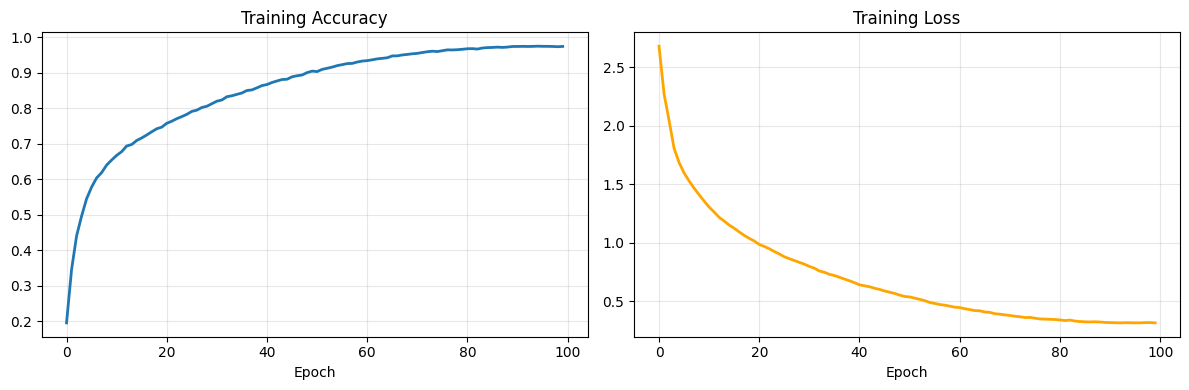

Final train accuracy: 97.36%


In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], linewidth=2)
axes[0].set_title('Training Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], linewidth=2, color='orange')
axes[1].set_title('Training Loss')
axes[1].set_xlabel('Epoch')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

print(f"Final train accuracy: {history.history['accuracy'][-1]*100:.2f}%")

## 11. Load Test Data & Predict with TTA
> 10 rounds of augmented predictions averaged together.

In [64]:
def predict_with_tta(model, images, n_rounds=10):
    all_preds = []
    for i in range(n_rounds):
        augmented = []
        for img in images:
            img_aug = img.copy()
            if np.random.rand() > 0.5:
                img_aug = np.fliplr(img_aug)
            # Match test image noise level
            noise = np.random.normal(0, 0.03, img_aug.shape)
            img_aug = np.clip(img_aug + noise, 0, 1)
            delta = np.random.uniform(-0.15, 0.15)
            img_aug = np.clip(img_aug + delta, 0, 1)
            augmented.append(img_aug)
        augmented = np.array(augmented, dtype=np.float32)
        preds = model.predict(augmented, verbose=0, batch_size=64)
        all_preds.append(preds)
        print(f"  TTA round {i+1}/{n_rounds} done")
    return np.mean(all_preds, axis=0)

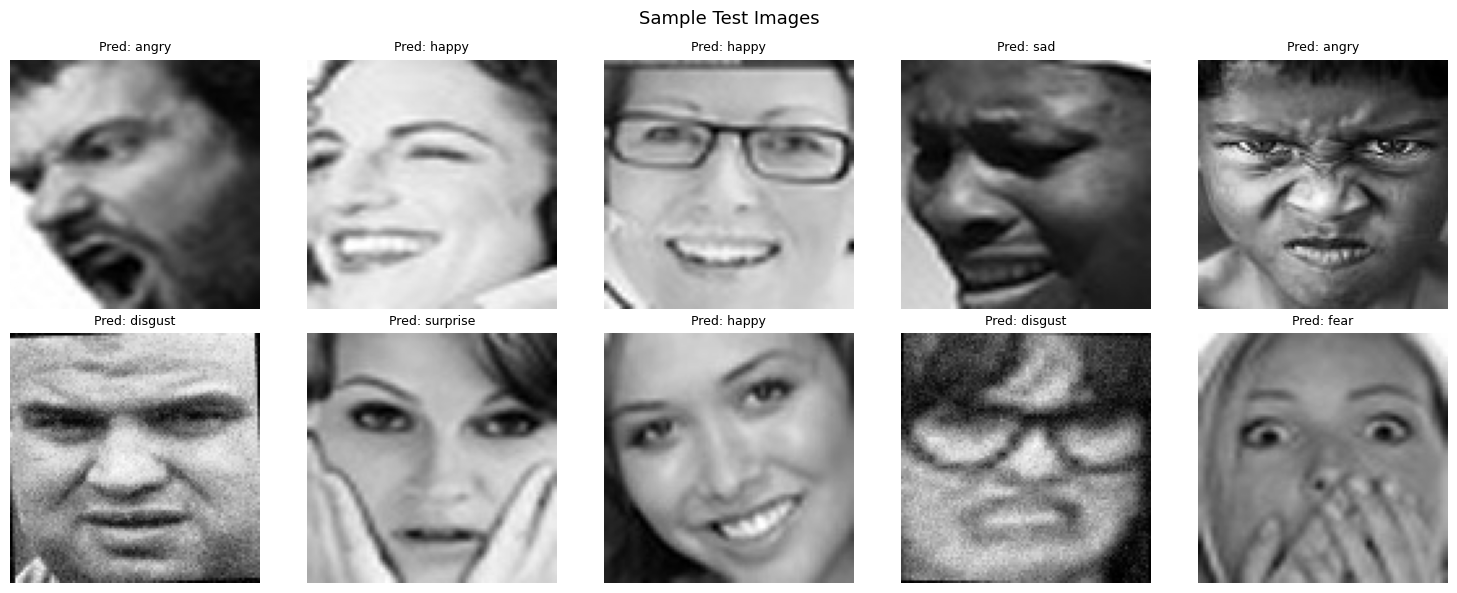

In [65]:
import matplotlib.pyplot as plt

# Show 10 random test images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    idx = np.random.randint(0, len(X_test))
    axes[i].imshow(X_test[idx].squeeze(), cmap='gray')
    axes[i].set_title(f"Pred: {pred_classes[idx]}", fontsize=9)
    axes[i].axis('off')

plt.suptitle('Sample Test Images', fontsize=13)
plt.tight_layout()
plt.show()

## 12. Save Submission

In [70]:
submission = pd.DataFrame({
    'ID'   : [os.path.splitext(f)[0] for f in test_filenames],  # remove .jpg
    'Label': pred_classes
})

submission.to_csv('submission.csv', index=False)
print("submission.csv saved!")
print(f"Total: {len(submission)} predictions")
print(submission.head(10))

submission.csv saved!
Total: 7116 predictions
            ID  Label
0     test (1)  angry
1    test (10)    sad
2   test (100)   fear
3  test (1000)  happy
4  test (1001)    sad
5  test (1002)  angry
6  test (1003)  happy
7  test (1004)   fear
8  test (1005)  angry
9  test (1006)    sad
